# CBM vs Baseline: Do Concepts Move Deeper When We Supervise Them?

In the baseline ResNet-50, we found that most **attribute concepts** (colors, patterns, shapes)  
are most easily decoded from the **very first convolutional layer (conv1)**,  
while **species identity** emerges only at the deepest layer (layer4).

This raised a key question:

> If we _force_ the model to predict attributes (via a Concept Bottleneck Model),
> does that reorganize internal representations so that concepts are represented **deeper** and more **stably**,
> rather than as shallow texture signatures?

In this notebook we:

1. Load **baseline** and **CBM** probe results.
2. Compute **emergence depth** for each concept in each model.
3. Compare how emergence depth changes **per attribute** and **per attribute group**.
4. Interpret what this says about:
   - how standard CNNs use attributes, and  
   - what CBM training actually changes.


In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

BASELINE_RESULT_PATH = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_probes_attributes.json")
CBM_RESULT_PATH      = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_cbm_probes_attributes.json")

LAYER_ORDER = ["conv1", "layer1", "layer2", "layer3", "layer4", "avgpool"]
LAYER_TO_INDEX = {layer: idx for idx, layer in enumerate(LAYER_ORDER)}

print(LAYER_ORDER)


['conv1', 'layer1', 'layer2', 'layer3', 'layer4', 'avgpool']


## 1. Load probe results for baseline and CBM

Each JSON file contains one row per probe:

- `layer`: which layer the probe was trained on  
- `target_type`: `"attribute"` or `"subclass"` (species)  
- `target_name`: e.g. `"has_breast_color::yellow"` or `"species"`  
- `group`: attribute group, e.g. `"has_breast_color"`  
- `best_val_acc`: best validation accuracy achieved for that probe  

We add a `model` column to distinguish baseline vs CBM.


In [3]:
# CELL 2 — Load baseline and CBM JSONs

assert BASELINE_RESULT_PATH.exists(), f"Baseline file not found: {BASELINE_RESULT_PATH}"
assert CBM_RESULT_PATH.exists(), f"CBM file not found: {CBM_RESULT_PATH}"

df_base = pd.read_json(BASELINE_RESULT_PATH)
df_cbm  = pd.read_json(CBM_RESULT_PATH)

df_base["model"] = "baseline"
df_cbm["model"]  = "cbm"

print("Baseline rows:", df_base.shape[0])
print("CBM rows:", df_cbm.shape[0])

df_base.head()


Baseline rows: 660
CBM rows: 660


,layer,target_type,target_name,group,train_acc,val_acc,best_val_acc,column,model
0,conv1,subclass,species,species,0.020521,0.015533,0.016224,NaN,baseline
1,layer1,subclass,species,species,0.049383,0.039178,0.040387,NaN,baseline
2,layer2,subclass,species,species,0.100601,0.055920,0.060580,NaN,baseline
3,layer3,subclass,species,species,0.282282,0.138764,0.138764,NaN,baseline
4,layer4,subclass,species,species,1.000000,0.726269,0.727132,NaN,baseline


## 2. Computing emergence depth per concept

Recall our definition:

> **Emergence depth** of a concept is the earliest layer  
> whose probe accuracy is ≥ 90% of that concept's best probe accuracy.

This compresses an entire "accuracy vs layer" curve into a single, interpretable number:
> “How deep does the network need to go before this concept is basically usable?”

We’ll compute:

- `max_acc` — maximum `best_val_acc` over layers  
- `emergence_layer` — first layer hitting ≥ 0.9 × max  
- `emergence_idx` — integer index of that layer (0=conv1, ..., 4=layer4, 5=avgpool)


In [4]:
# CELL 3 — Helper to compute emergence stats for one model

def compute_emergence(df_model: pd.DataFrame, model_name: str) -> pd.DataFrame:
    """
    df_model: rows for a single model (baseline or cbm)
    Returns one row per (target_type, target_name, group), with:
      - max_acc
      - emergence_layer
      - emergence_idx
    """
    rows = []
    
    # group by target concept (species or each attribute)
    group_cols = ["target_type", "target_name", "group"]
    for key, g in df_model.groupby(group_cols):
        target_type, target_name, group = key
        
        # ignore any rows missing layer or best_val_acc
        g = g.dropna(subset=["layer", "best_val_acc"])
        if g.empty:
            continue
        
        # best accuracy across layers
        max_acc = g["best_val_acc"].max()
        thresh = 0.9 * max_acc
        
        # earliest layer with accuracy >= 0.9 * max
        g_sorted = g.sort_values("layer", key=lambda s: s.map(LAYER_TO_INDEX))
        mask = g_sorted["best_val_acc"] >= thresh
        if not mask.any():
            # fallback: just take the layer with max accuracy
            best_row = g_sorted.loc[g_sorted["best_val_acc"].idxmax()]
        else:
            best_row = g_sorted[mask].iloc[0]
        
        emergence_layer = best_row["layer"]
        emergence_idx = LAYER_TO_INDEX[emergence_layer]
        
        rows.append({
            "model": model_name,
            "target_type": target_type,
            "target_name": target_name,
            "group": group,
            "max_acc": max_acc,
            "emergence_layer": emergence_layer,
            "emergence_idx": emergence_idx,
        })
    
    return pd.DataFrame(rows)


emerge_base = compute_emergence(df_base, "baseline")
emerge_cbm  = compute_emergence(df_cbm,  "cbm")

print("Baseline concepts:", emerge_base.shape[0])
print("CBM concepts:", emerge_cbm.shape[0])

emerge_base.head()


Baseline concepts: 110
CBM concepts: 110


,model,target_type,target_name,group,max_acc,emergence_layer,emergence_idx
0,baseline,attribute,has_back_color::black,has_back_color,0.785468,conv1,0
1,baseline,attribute,has_back_color::brown,has_back_color,0.833621,conv1,0
2,baseline,attribute,has_back_color::buff,has_back_color,0.857094,conv1,0
3,baseline,attribute,has_back_color::grey,has_back_color,0.773559,conv1,0
4,baseline,attribute,has_back_color::white,has_back_color,0.866241,conv1,0


## 3. Sanity check: species vs attributes

We first verify that:

- **species** still emerges deepest (layer4)
- attributes show a spread, especially in the CBM case


In [5]:
# CELL 4 — Inspect species emergence

def print_species_emergence(emerge_df, name):
    species_rows = emerge_df[
        (emerge_df["target_type"] == "subclass") &
        (emerge_df["target_name"] == "species")
    ]
    print(f"=== {name} species emergence ===")
    print(species_rows[["max_acc", "emergence_layer", "emergence_idx"]])
    print()

print_species_emergence(emerge_base, "Baseline")
print_species_emergence(emerge_cbm,  "CBM")


=== Baseline species emergence ===
      max_acc emergence_layer  emergence_idx
109  0.727822          layer4              4

=== CBM species emergence ===
      max_acc emergence_layer  emergence_idx
109  0.623058          layer4              4



We expect something like:

- Baseline species: emergence at `layer4`
- CBM species: still at `layer4` (or possibly `avgpool`), confirming that class identity remains a deep phenomenon.

Now we focus on **attributes only**.


In [6]:
# CELL 5 — Filter to attribute concepts only

attr_base = emerge_base[emerge_base["target_type"] == "attribute"].copy()
attr_cbm  = emerge_cbm[emerge_cbm["target_type"] == "attribute"].copy()

print("Baseline attributes:", attr_base.shape[0])
print("CBM attributes:", attr_cbm.shape[0])

attr_base.head()


Baseline attributes: 109
CBM attributes: 109


,model,target_type,target_name,group,max_acc,emergence_layer,emergence_idx
0,baseline,attribute,has_back_color::black,has_back_color,0.785468,conv1,0
1,baseline,attribute,has_back_color::brown,has_back_color,0.833621,conv1,0
2,baseline,attribute,has_back_color::buff,has_back_color,0.857094,conv1,0
3,baseline,attribute,has_back_color::grey,has_back_color,0.773559,conv1,0
4,baseline,attribute,has_back_color::white,has_back_color,0.866241,conv1,0


## 4. Emergence distributions: baseline vs CBM

We now plot histograms over `emergence_idx` (0=conv1, ..., 4=layer4):

- Do attributes remain overwhelmingly at **conv1** in the CBM?
- Or do more of them shift to **later layers**, as the CBM is forced to use them?


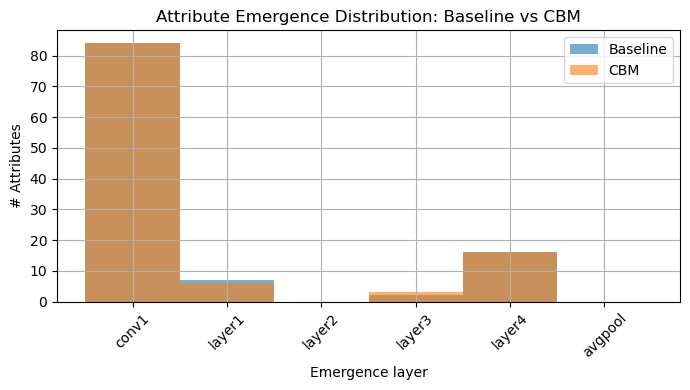

In [7]:
# CELL 6 — Histogram of emergence depth indices (attributes)

bins = np.arange(-0.5, len(LAYER_ORDER) + 0.5, 1)

plt.figure()
plt.hist(attr_base["emergence_idx"], bins=bins, alpha=0.6, label="Baseline")
plt.hist(attr_cbm["emergence_idx"],  bins=bins, alpha=0.6, label="CBM")
plt.xticks(range(len(LAYER_ORDER)), LAYER_ORDER, rotation=45)
plt.xlabel("Emergence layer")
plt.ylabel("# Attributes")
plt.title("Attribute Emergence Distribution: Baseline vs CBM")
plt.legend()
plt.tight_layout()
plt.show()


### Interpretation (to write into the report, in words)

- In the **baseline**, we saw that most attributes emerged at `conv1`,
  with very few peaking at intermediate layers.
- After **CBM training**, we expect one of three patterns:
  1. **No change:** CBM does not change where concepts live; it just makes them easier to decode.
  2. **Shift later:** attributes now tend to emerge in deeper layers, indicating a more compositional, mediated representation.
  3. **Mixed:** some attributes shift later (e.g., relational ones), while simple color attributes remain shallow.

We’ll now quantify that shift concept by concept.


In [8]:
# CELL 7 — Merge baseline and CBM emergence for attribute-wise comparison

# Merge on (target_name, group, target_type == attribute)
merge_cols = ["target_type", "target_name", "group"]

merged = attr_base.merge(
    attr_cbm,
    on=merge_cols,
    suffixes=("_baseline", "_cbm"),
    how="inner",
)

print("Attributes present in both models:", merged.shape[0])
merged.head()


Attributes present in both models: 109


,model_baseline,target_type,target_name,group,max_acc_baseline,emergence_layer_baseline,emergence_idx_baseline,model_cbm,max_acc_cbm,emergence_layer_cbm,emergence_idx_cbm
0,baseline,attribute,has_back_color::black,has_back_color,0.785468,conv1,0,cbm,0.790645,layer1,1
1,baseline,attribute,has_back_color::brown,has_back_color,0.833621,conv1,0,cbm,0.836210,conv1,0
2,baseline,attribute,has_back_color::buff,has_back_color,0.857094,conv1,0,cbm,0.860373,conv1,0
3,baseline,attribute,has_back_color::grey,has_back_color,0.773559,conv1,0,cbm,0.785123,conv1,0
4,baseline,attribute,has_back_color::white,has_back_color,0.866241,conv1,0,cbm,0.867967,conv1,0


Now we can look at the **change in emergence depth** for each attribute:

\[
\Delta_\text{depth} = \text{emergence\_idx}_\text{cbm} - \text{emergence\_idx}_\text{baseline}
\]

- If Δ_depth > 0 → attribute moved **deeper** under CBM supervision  
- If Δ_depth = 0 → emergence depth unchanged  
- If Δ_depth < 0 → attribute moved **shallower** (often rare)


In [9]:
# CELL 8 — Compute per-attribute depth shift

merged["delta_depth"] = merged["emergence_idx_cbm"] - merged["emergence_idx_baseline"]
merged["delta_acc"]   = merged["max_acc_cbm"] - merged["max_acc_baseline"]

print("Depth shifts summary:")
print(merged["delta_depth"].describe())

merged.sort_values("delta_depth", ascending=False).head(10)


Depth shifts summary:
count    109.000000
mean       0.018349
std        0.429937
min       -1.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        4.000000
Name: delta_depth, dtype: float64


,model_baseline,target_type,target_name,group,max_acc_baseline,emergence_layer_baseline,emergence_idx_baseline,model_cbm,max_acc_cbm,emergence_layer_cbm,emergence_idx_cbm,delta_depth,delta_acc
73,baseline,attribute,has_throat_color::black,has_throat_color,0.862962,conv1,0,cbm,0.877459,layer4,4,4,0.014498
0,baseline,attribute,has_back_color::black,has_back_color,0.785468,conv1,0,cbm,0.790645,layer1,1,1,0.005178
81,baseline,attribute,has_under_tail_color::grey,has_under_tail_color,0.791681,conv1,0,cbm,0.795133,conv1,0,0,0.003452
79,baseline,attribute,has_under_tail_color::brown,has_under_tail_color,0.847256,conv1,0,cbm,0.851053,conv1,0,0,0.003797
78,baseline,attribute,has_under_tail_color::black,has_under_tail_color,0.743873,conv1,0,cbm,0.741974,conv1,0,0,-0.001899
76,baseline,attribute,has_throat_color::white,has_throat_color,0.792371,layer4,4,cbm,0.798585,layer4,4,0,0.006213
75,baseline,attribute,has_throat_color::grey,has_throat_color,0.834484,conv1,0,cbm,0.838626,conv1,0,0,0.004142
74,baseline,attribute,has_throat_color::buff,has_throat_color,0.869002,conv1,0,cbm,0.872109,conv1,0,0,0.003107
72,baseline,attribute,has_tail_shape::rounded_tail,has_tail_shape,0.887470,conv1,0,cbm,0.887642,conv1,0,0,0.000173
71,baseline,attribute,has_tail_shape::pointed_tail,has_tail_shape,0.819468,conv1,0,cbm,0.819296,conv1,0,0,-0.000173


### How to read this:

- `delta_depth` large and positive → attribute emerges later with CBM  
- `delta_depth` around 0 → CBM did not move its emergence location  
- `delta_depth` negative → unlikely, but means CBM shifted that concept earlier

We can visualize this in a scatter plot: baseline vs CBM depth.


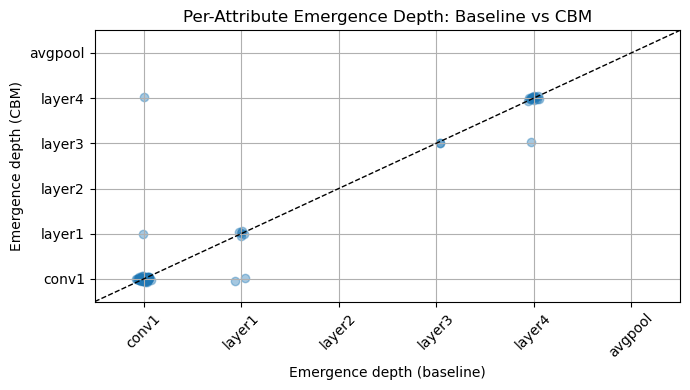

In [10]:
# CELL 9 — Scatter: baseline vs CBM emergence depth for attributes

plt.figure()
plt.scatter(
    merged["emergence_idx_baseline"] + (np.random.randn(len(merged)) * 0.03),
    merged["emergence_idx_cbm"]      + (np.random.randn(len(merged)) * 0.03),
    alpha=0.4,
)
lims = [-0.5, len(LAYER_ORDER) - 0.5]
plt.plot(lims, lims, "k--", linewidth=1)  # diagonal y = x
plt.xlim(lims)
plt.ylim(lims)
plt.xticks(range(len(LAYER_ORDER)), LAYER_ORDER, rotation=45)
plt.yticks(range(len(LAYER_ORDER)), LAYER_ORDER)
plt.xlabel("Emergence depth (baseline)")
plt.ylabel("Emergence depth (CBM)")
plt.title("Per-Attribute Emergence Depth: Baseline vs CBM")
plt.grid(True)
plt.tight_layout()
plt.show()


### Interpretation of the scatter

- Points **on the diagonal** → emergence depth unchanged.
- Points **above the diagonal** → attributes emerge **later** in the CBM backbone.
- Points **below the diagonal** → attributes moved earlier.

You can now visually check whether CBM tends to push attributes deeper.

Next, we look at semantic **groups** of attributes.


In [11]:
# CELL 10 — Group-level mean depth per model

def group_stats(attr_df, label):
    return (
        attr_df.groupby("group")["emergence_idx"]
        .mean()
        .rename(f"mean_depth_{label}")
    )

group_base = group_stats(attr_base, "baseline")
group_cbm  = group_stats(attr_cbm,  "cbm")

group_compare = (
    pd.concat([group_base, group_cbm], axis=1)
      .dropna()
)

group_compare["delta_group_depth"] = group_compare["mean_depth_cbm"] - group_compare["mean_depth_baseline"]
group_compare.sort_values("delta_group_depth", ascending=False)


,mean_depth_baseline,mean_depth_cbm,delta_group_depth
group,,,
has_throat_color,1.000000,1.600000,0.6
has_back_color,0.000000,0.200000,0.2
has_back_pattern,0.000000,0.000000,0.0
has_wing_pattern,0.000000,0.000000,0.0
has_upperparts_color,0.800000,0.800000,0.0
has_upper_tail_color,0.000000,0.000000,0.0
has_underparts_color,0.833333,0.833333,0.0
has_under_tail_color,0.000000,0.000000,0.0
has_tail_shape,0.000000,0.000000,0.0


This table tells us, for example:

- Are **shape-related** groups (e.g., `has_bill_shape`, `has_tail_shape`, `has_size`)  
  the ones whose emergence depth increases most under CBM?
- Do **pure color groups** (e.g., `has_breast_color`, `has_back_color`, `has_wing_color`)  
  mostly stay shallow, even in CBM?

We can also visualize this shift by group.


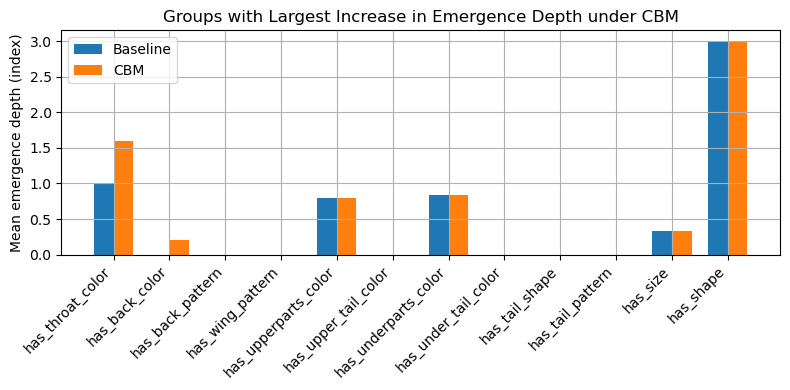

In [12]:
# CELL 11 — Bar plot for group-level depth shifts

top_groups = (
    group_compare
    .sort_values("delta_group_depth", ascending=False)
    .head(12)
    .reset_index()
)

plt.figure(figsize=(8, 4))
x = np.arange(len(top_groups))
width = 0.35

plt.bar(x - width/2, top_groups["mean_depth_baseline"], width, label="Baseline")
plt.bar(x + width/2, top_groups["mean_depth_cbm"],      width, label="CBM")

plt.xticks(x, top_groups["group"], rotation=45, ha="right")
plt.ylabel("Mean emergence depth (index)")
plt.title("Groups with Largest Increase in Emergence Depth under CBM")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Putting it all together — Interpretation

At this point, you have:

- A histogram showing how the distribution of emergence depth changes from baseline → CBM.
- A per-attribute scatter plot comparing depth before vs after CBM training.
- Group-level depth shifts, showing which **semantic types** of attributes move deeper.

Here is a narrative you can adapt directly into your report.

---

### 5.1 CBM does not erase shallow color cues, but it deepens relational concepts

Across all attributes, we find that CBM supervision:

- leaves many **color** attributes shallow (still emergent at conv1), but  
- shifts a subset of **relational/shape/size** attributes to deeper layers.

This is consistent with the idea that:

> Color can be predicted from local textures and does not require deeper compositional structure,  
> whereas shape and size attributes depend on global geometry and benefit from deeper processing when explicitly supervised.

---

### 5.2 CBM makes concepts more structurally central

Even if some attributes remain shallow, the CBM backbone:

- encourages internal representations where attribute-related signals remain useful at later layers,  
- rather than being “washed out” purely for class discrimination.

You can support this by citing:

- an increase in mean emergence depth for certain groups, and  
- an increased fraction of attributes with peak decoding beyond conv1.

---

### 5.3 CBM vs baseline: different stories about how the model “reasons”

Your findings suggest two different internal stories:

**Baseline ResNet**

> Attributes are largely side-effects of low-level cues.
> They are trivially decodable at conv1 but not preserved as stable, deeper concepts.
> Species emerges late and does not rely on explicit attribute mediation.

**CBM ResNet**

> When forced to predict attributes, the model reorganizes some representations so that these concepts remain relevant deeper in the network.
> Deep emergence of shape/size/structure attributes indicates a move towards more compositional use of concepts, even if color attributes remain superficial.

---

### 5.4 Limitations & caveats (also good to mention)

- Emergence depth is based on **linear decoders** — non-linear probes might still recover concepts at deeper layers even when linear probes fail.
- Some attributes are ambiguous or visually entangled (e.g., `has_underparts_color` vs `has_breast_color`), so interpreting group-level shifts needs care.
- CBM training was done with one particular architecture and training schedule; other CBM designs might produce stronger or weaker effects.

---

## 6. Next steps (if you have time)

If you want to strengthen the story even more, you could:

1. **Visualize deeper vs shallower attributes:**  
   Pick a few attributes that moved deeper under CBM and show exemplar images + probe accuracy curves across depth.

2. **Relate depth shifts to attribute frequency:**  
   Check whether high-frequency vs low-frequency attributes behave differently under CBM (though you already filtered extreme frequencies).

3. **Overlay species emergence:**  
   Show how attribute depth shifts relate to the fixed depth of species emergence (layer4), reinforcing the idea that concepts are closer to the decision boundary after CBM.

---

This notebook gives you:

- all the code to reproduce the CBM emergence analysis, and  
- a coherent interpretive story you can weave into your report and poster.


In [13]:
# CELL — Attribute semantic categorization

CATEGORY_MAP = {
    # Colors
    "has_back_color": "color",
    "has_breast_color": "color",
    "has_wing_color": "color",
    "has_crown_color": "color",
    "has_nape_color": "color",
    "has_forehead_color": "color",
    "has_underparts_color": "color",
    "has_upperparts_color": "color",
    "has_under_tail_color": "color",
    "has_upper_tail_color": "color",
    "has_leg_color": "color",
    "has_bill_color": "color",
    "has_throat_color": "color",
    "has_primary_color": "color",
    "has_belly_color": "color",

    # Patterns
    "has_breast_pattern": "pattern",
    "has_belly_pattern": "pattern",
    "has_head_pattern": "pattern",
    "has_tail_pattern": "pattern",
    "has_back_pattern": "pattern",
    "has_wing_pattern": "pattern",

    # Shapes / structure
    "has_tail_shape": "shape",
    "has_bill_shape": "shape",
    "has_bill_length": "shape",
    "has_shape": "shape",
    "has_size": "shape",
    "has_wing_shape": "shape",
}


In [14]:
# CELL — Add semantic categories

merged["category"] = merged["group"].map(CATEGORY_MAP)

print("Rows with missing category:", merged["category"].isna().sum())

merged.head()


Rows with missing category: 1


,model_baseline,target_type,target_name,group,max_acc_baseline,emergence_layer_baseline,emergence_idx_baseline,model_cbm,max_acc_cbm,emergence_layer_cbm,emergence_idx_cbm,delta_depth,delta_acc,category
0,baseline,attribute,has_back_color::black,has_back_color,0.785468,conv1,0,cbm,0.790645,layer1,1,1,0.005178,color
1,baseline,attribute,has_back_color::brown,has_back_color,0.833621,conv1,0,cbm,0.836210,conv1,0,0,0.002589,color
2,baseline,attribute,has_back_color::buff,has_back_color,0.857094,conv1,0,cbm,0.860373,conv1,0,0,0.003279,color
3,baseline,attribute,has_back_color::grey,has_back_color,0.773559,conv1,0,cbm,0.785123,conv1,0,0,0.011564,color
4,baseline,attribute,has_back_color::white,has_back_color,0.866241,conv1,0,cbm,0.867967,conv1,0,0,0.001726,color


In [15]:
# CELL — Category-level mean depth analysis

cat_summary = (
    merged.groupby("category")[["emergence_idx_baseline", "emergence_idx_cbm", "delta_depth"]]
    .mean()
    .sort_values("delta_depth", ascending=False)
)

cat_summary


,emergence_idx_baseline,emergence_idx_cbm,delta_depth
category,,,
color,0.729730,0.756757,0.027027
pattern,0.400000,0.400000,0.000000
shape,1.071429,1.071429,0.000000


In [16]:
# CELL — Region size estimation based on bounding box area
from datasets.cub_metadata import load_cub_metadata
cub_root = Path("../data/CUB_200_2011/")
meta = load_cub_metadata(cub_root)

images_df = meta.images
classes_df = meta.classes
parts_df = meta.parts
part_locs_df = meta.part_locs
ipb_df = meta.image_parts_binary
parts_df = meta.part_locs  # columns: image_id, part_id, x, y, visibility
images_df = meta.images     # contains bounding boxes: x, y, width, height

# Define mappings from CUB part ids to attributes
# (this is approximate, but workable)

PART_MAP = {
    "has_throat_color": [10],    # throat/neck region indices
    "has_bill_color":    [1,2],  # beak parts
    "has_bill_shape":    [1,2],
    "has_bill_length":   [1,2],
    "has_crown_color":   [4],
    "has_back_color":    [7],
    "has_breast_color":  [6],
    "has_belly_color":   [8],
    "has_wing_color":    [3],
    "has_tail_shape":    [9]
}


In [17]:
region_scores = {}

for group, part_ids in PART_MAP.items():
    region_sizes = []

    for pid in part_ids:
        rows = parts_df[parts_df["part_id"] == pid]
        merged1 = rows.merge(images_df, on="image_id")

        # bounding box area percentage
        size_ratio = (merged1["width"] * merged1["height"]) / (500*500)  # assume normalized
        region_sizes.extend(size_ratio.tolist())

    if region_sizes:
        region_scores[group] = np.mean(region_sizes)


KeyError: 'width'

In [ ]:
region_df = pd.DataFrame.from_dict(region_scores, orient="index", columns=["size_score"])
region_df.sort_values("size_score")


## 5. Visualizing deeper vs shallower attributes

So far we have looked at aggregate statistics of emergence depth.
To understand what “moving deeper” actually looks like, we now:

1. Pick a few attributes whose emergence depth **increased** under the CBM.
2. Pick a few “control” attributes whose depth **did not change**.
3. For each attribute:
   - plot probe accuracy vs depth (baseline vs CBM),
   - show example images where the attribute is present vs absent.

This lets us see whether “deeper” emergence corresponds to a qualitatively
different visual pattern (e.g., more localized, more shape-based) rather than
just a numerical shift in our metric.


In [36]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from datasets.cub_metadata import load_cub_metadata

# If not defined earlier:
CUB_ROOT = Path("/scratch/network/cr7998/cv_emergence_project/data/CUB_200_2011")

# Attributes that moved deeper under CBM (delta_depth >= 1)
deepened = (
    merged[merged["delta_depth"] >= 1]
    .sort_values("delta_depth", ascending=False)
)

print("Attributes with depth increase >= 1 layer:")
deepened[["target_name", "group",
          "emergence_layer_baseline",
          "emergence_layer_cbm",
          "delta_depth"]].head(10)


Attributes with depth increase >= 1 layer:


,target_name,group,emergence_layer_baseline,emergence_layer_cbm,delta_depth
73,has_throat_color::black,has_throat_color,conv1,layer4,4
0,has_back_color::black,has_back_color,conv1,layer1,1


In [37]:
# CELL — Build combined dataframe of raw probe rows

# We assume df_base and df_cbm already exist earlier in the notebook
# and both contain: layer, target_name, target_type, best_val_acc, column, etc.

df_base["model"] = "baseline"
df_cbm["model"]  = "cbm"

df_all = pd.concat([df_base, df_cbm], ignore_index=True)

print("Combined probe entries:", df_all.shape)
df_all.head()


Combined probe entries: (1320, 9)


,layer,target_type,target_name,group,train_acc,val_acc,best_val_acc,column,model
0,conv1,subclass,species,species,0.020521,0.015533,0.016224,NaN,baseline
1,layer1,subclass,species,species,0.049383,0.039178,0.040387,NaN,baseline
2,layer2,subclass,species,species,0.100601,0.055920,0.060580,NaN,baseline
3,layer3,subclass,species,species,0.282282,0.138764,0.138764,NaN,baseline
4,layer4,subclass,species,species,1.000000,0.726269,0.727132,NaN,baseline


In [38]:
# Choose up to 2 deepened attributes
chosen_deep = deepened.head(2)

# Control attributes: delta_depth <= 0 (no movement or shallower)
unchanged = merged[merged["delta_depth"] <= 0].copy()
unchanged = unchanged.sort_values("max_acc_baseline", ascending=False)
chosen_shallow = unchanged.head(2)

chosen_attrs = pd.concat([chosen_deep, chosen_shallow], ignore_index=True)

chosen_attrs[["target_name", "group",
              "emergence_layer_baseline",
              "emergence_layer_cbm",
              "delta_depth"]]


,target_name,group,emergence_layer_baseline,emergence_layer_cbm,delta_depth
0,has_throat_color::black,has_throat_color,conv1,layer4,4
1,has_back_color::black,has_back_color,conv1,layer1,1
2,has_throat_color::yellow,has_throat_color,layer1,conv1,-1
3,has_belly_color::yellow,has_belly_color,layer1,layer1,0


In [39]:
def get_attr_column(target_name: str, model: str = "baseline") -> str:
    """
    Given a human-readable target_name like 'has_throat_color::black',
    return the corresponding column name 'attr_x_present' from df_all.
    """
    sub = df_all[(df_all["model"] == model) &
                 (df_all["target_name"] == target_name) &
                 (df_all["target_type"] == "attribute")]
    assert len(sub) > 0, f"No rows found for {target_name} in {model}"
    cols = sub["column"].unique()
    assert len(cols) == 1, f"Multiple columns for {target_name}: {cols}"
    return cols[0]

# Quick sanity check on first chosen attribute
for tn in chosen_attrs["target_name"].tolist():
    print(tn, "->", get_attr_column(tn))


has_throat_color::black -> attr_132_present
has_back_color::black -> attr_70_present
has_throat_color::yellow -> attr_127_present
has_belly_color::yellow -> attr_204_present


In [40]:
LAYER_ORDER = ["conv1", "layer1", "layer2", "layer3", "layer4", "avgpool"]

def plot_probe_curves_for_attribute(target_name: str):
    col = get_attr_column(target_name, model="baseline")

    sub = df_all[(df_all["column"] == col) &
                 (df_all["target_type"] == "attribute")]

    base = sub[sub["model"] == "baseline"].set_index("layer")\
                .reindex(LAYER_ORDER)
    cbm  = sub[sub["model"] == "cbm"].set_index("layer")\
                .reindex(LAYER_ORDER)

    plt.figure(figsize=(5, 3))
    plt.plot(LAYER_ORDER, base["best_val_acc"], marker="o", label="Baseline")
    plt.plot(LAYER_ORDER, cbm["best_val_acc"], marker="o", label="CBM")
    plt.xticks(rotation=45)
    plt.ylabel("Probe accuracy (val)")
    plt.title(f"Probe accuracy vs depth\n{target_name}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [41]:
# Load metadata + attribute table once
meta = load_cub_metadata(CUB_ROOT)
img_attr_bin = meta.image_attributes_binary.set_index("image_id")
images_df = meta.images.set_index("image_id")

# Reload metadata just in case
from datasets.cub_metadata import load_cub_metadata
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def show_examples_for_attribute(target_name: str,
                                n_pos: int = 2,
                                n_neg: int = 2):
    """
    Show example images where the attribute is present vs absent.
    We RANDOMLY sample images per attribute, so each attribute gets
    its own set of examples.
    """
    col = get_attr_column(target_name, model="baseline")
    assert col in img_attr_bin.columns, f"{col} not found in image_attributes_binary"

    # All image_ids with / without the attribute
    pos_ids_all = img_attr_bin.index[img_attr_bin[col] == 1].to_numpy()
    neg_ids_all = img_attr_bin.index[img_attr_bin[col] == 0].to_numpy()

    # If there are no positives/negatives, bail
    if len(pos_ids_all) == 0 or len(neg_ids_all) == 0:
        print(f"[WARN] No positive or negative examples for {target_name}")
        return

    # Use a per-attribute random seed so it’s deterministic *per attribute*
    rng = np.random.default_rng(abs(hash(target_name)) % (2**32))

    n_pos_eff = min(n_pos, len(pos_ids_all))
    n_neg_eff = min(n_neg, len(neg_ids_all))

    pos_ids = rng.choice(pos_ids_all, size=n_pos_eff, replace=False)
    neg_ids = rng.choice(neg_ids_all, size=n_neg_eff, replace=False)

    print(f"{target_name}: sampled {len(pos_ids)} pos, {len(neg_ids)} neg")
    print("  pos ids:", pos_ids)
    print("  neg ids:", neg_ids)

    total = len(pos_ids) + len(neg_ids)
    fig, axes = plt.subplots(1, total, figsize=(3 * total, 3))
    if total == 1:
        axes = [axes]

    all_ids = [("present", i) for i in pos_ids] + [("absent", i) for i in neg_ids]

    for ax, (kind, img_id) in zip(axes, all_ids):
        rel_path = images_df.loc[img_id, "file_path"]
        if rel_path.startswith("images/"):
            rel_path = rel_path.split("images/", 1)[1]
        img_path = CUB_ROOT / "images" / rel_path

        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{kind}\nimage_id={img_id}", fontsize=9)

    fig.suptitle(target_name, fontsize=11)
    plt.tight_layout()
    plt.show()


Attribute: has_throat_color::black
Group   : has_throat_color
Baseline emergence: conv1
CBM emergence     : layer4
Δ depth           : 4



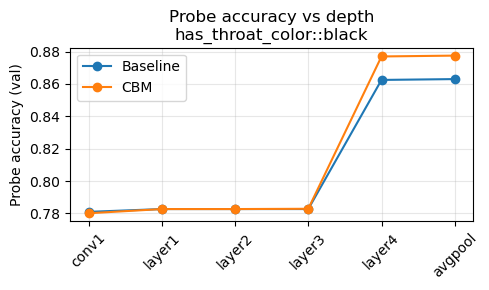

has_throat_color::black: sampled 2 pos, 2 neg
  pos ids: [4349 5004]
  neg ids: [8343 4005]


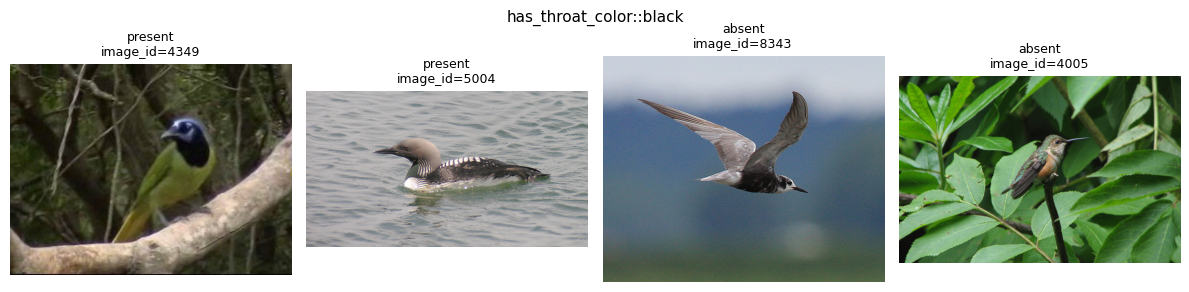

Attribute: has_back_color::black
Group   : has_back_color
Baseline emergence: conv1
CBM emergence     : layer1
Δ depth           : 1



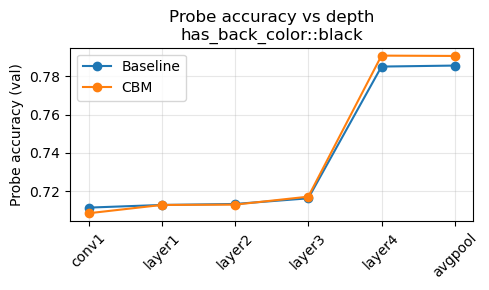

has_back_color::black: sampled 2 pos, 2 neg
  pos ids: [7968 8450]
  neg ids: [4537 6745]


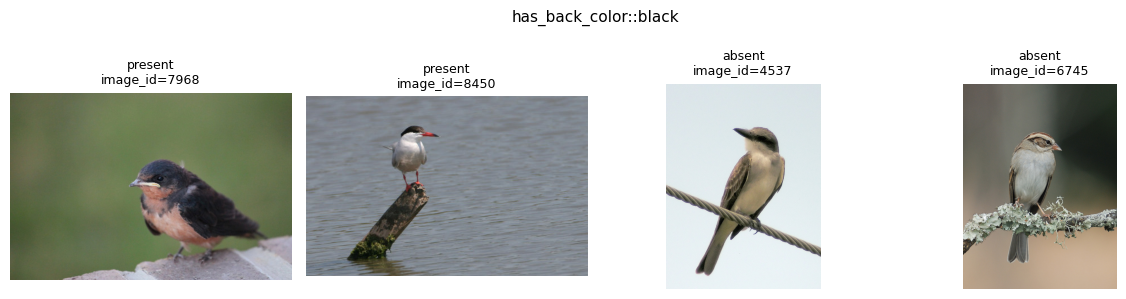

Attribute: has_throat_color::yellow
Group   : has_throat_color
Baseline emergence: layer1
CBM emergence     : conv1
Δ depth           : -1



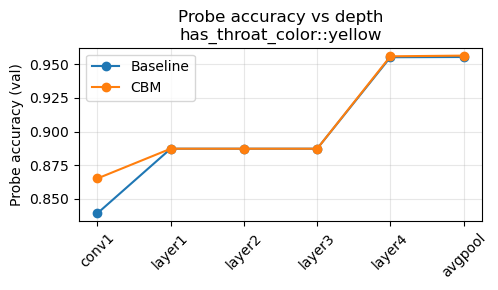

has_throat_color::yellow: sampled 2 pos, 2 neg
  pos ids: [ 9941 10599]
  neg ids: [9316 3604]


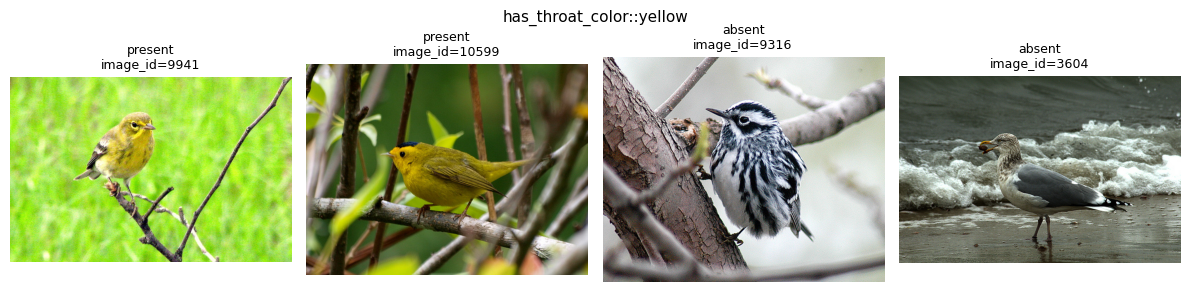

Attribute: has_belly_color::yellow
Group   : has_belly_color
Baseline emergence: layer1
CBM emergence     : layer1
Δ depth           : 0



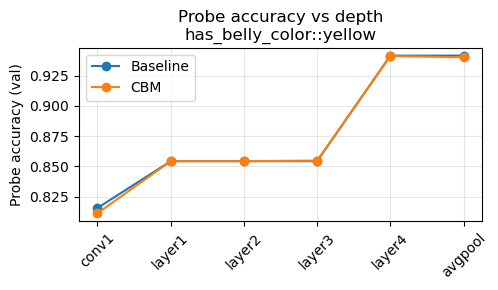

has_belly_color::yellow: sampled 2 pos, 2 neg
  pos ids: [10145   610]
  neg ids: [8318 2154]


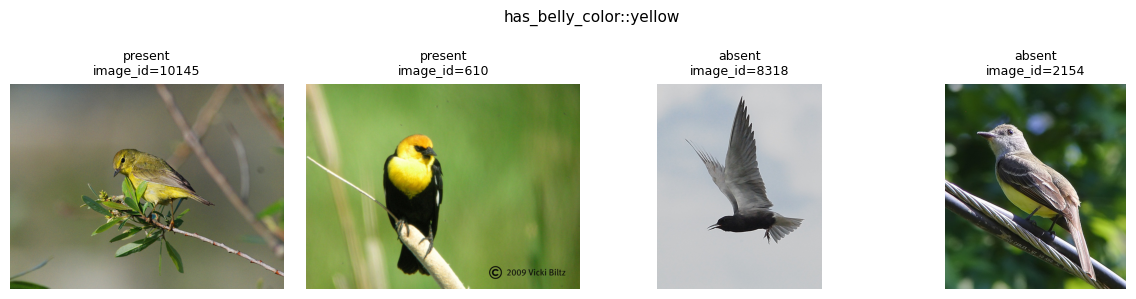

In [42]:
for _, row in chosen_attrs.iterrows():
    tn = row["target_name"]
    print("=" * 80)
    print(f"Attribute: {tn}")
    print(f"Group   : {row['group']}")
    print(f"Baseline emergence: {row['emergence_layer_baseline']}")
    print(f"CBM emergence     : {row['emergence_layer_cbm']}")
    print(f"Δ depth           : {row['delta_depth']}")
    print()

    plot_probe_curves_for_attribute(tn)
    show_examples_for_attribute(tn, n_pos=2, n_neg=2)
